<a href="https://colab.research.google.com/github/evmpython/mascarar_regiao/blob/main/recortar_shapefile.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

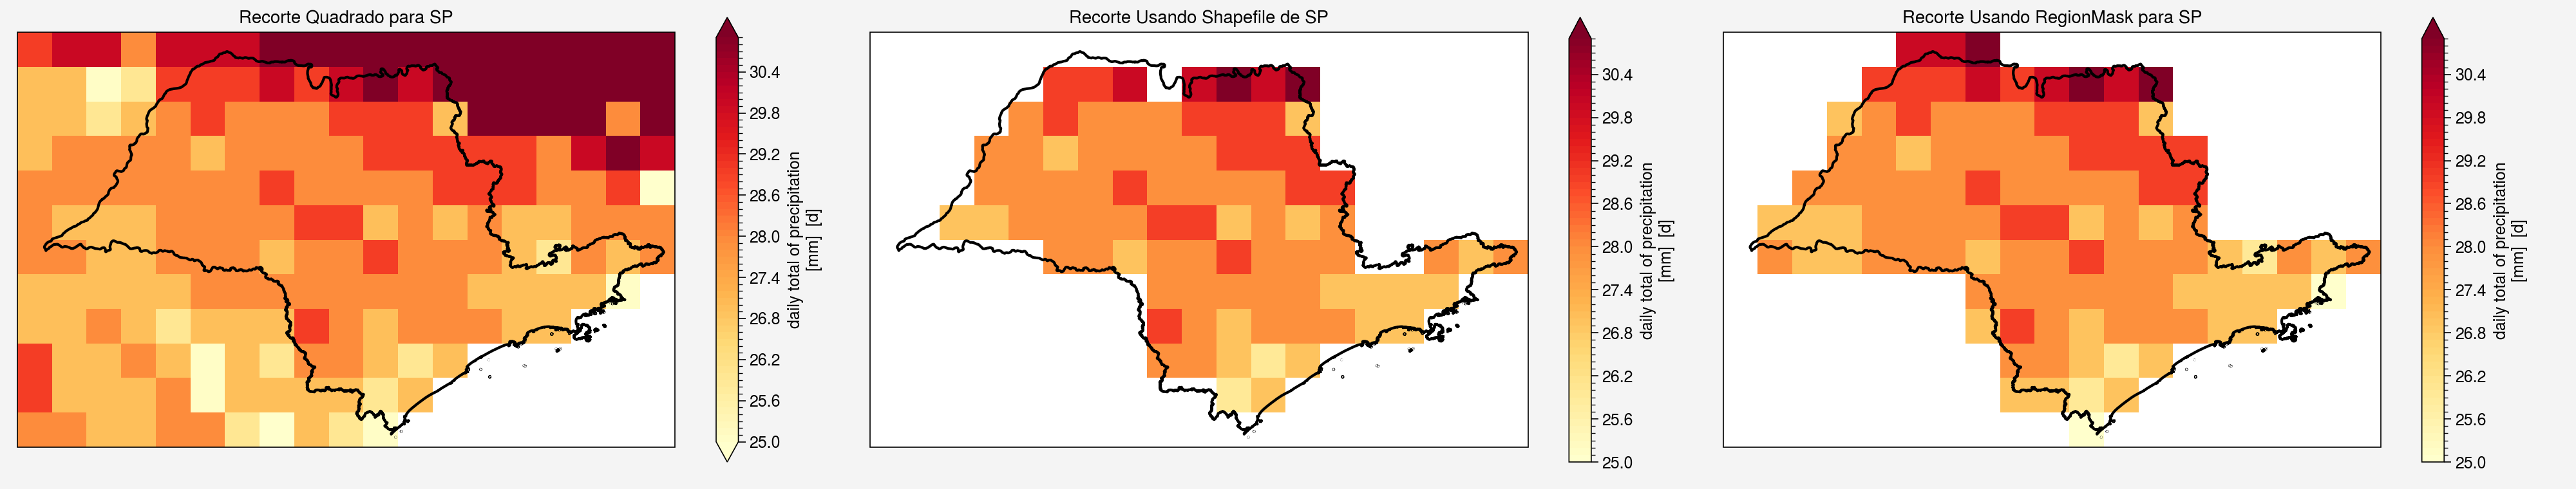

In [58]:
#=========================================================================================================================#
#                                          INSTALAÇÃO E IMPORTAÇÃO DAS BIBLIOTECAS
#=========================================================================================================================#
# instala bibliotecas
!pip install -q xarray dask netCDF4 bottleneck xclim ultraplot cartopy salem rasterio pyproj geopandas regionmask rioxarray

# importa bibliotecas
import xarray as xr
import xclim as xc
import ultraplot as uplt
import salem
import os
import cartopy.io.shapereader as shpreader
import cartopy.crs as ccrs
import numpy as np
from dask.diagnostics import ProgressBar
from matplotlib.ticker import FormatStrFormatter
import matplotlib.pyplot as plt
import regionmask
import geopandas as gpd
import rioxarray
from shapely.geometry import mapping
import warnings
warnings.filterwarnings("ignore")

#=========================================================================================================================#
#                                  DEFINE OS LIMITES DO BRASIL OU ESTADO DE SÃO PAULO
#=========================================================================================================================#
# limites
lonmin_sp, lonmax_sp, latmin_sp, latmax_sp = -53.3, -43.9, -25.4, -19.7 # estado de SP
lonmin_br, lonmax_br, latmin_br, latmax_br = -75.0, -33.0, -35.0, 7.0 # Brasil

# leitura shapefiles
shapefile_sp = salem.read_shapefile('https://github.com/evmpython/shapefile/raw/main/UFs/SP/SP_UF_2019.shp') # estado de SP
shapefile_br = salem.read_shapefile('https://github.com/evmpython/shapefile/raw/main/brasil/BRAZIL.shp') # Brasil

#=========================================================================================================================#
#                                            RECORTANDO O DADO
#=========================================================================================================================#
# Define the URL for the NetCDF file
nc_url = "https://github.com/evmpython/mascarar_regiao/raw/main/dry_days_cpc_2024-08-01_2024-08-31.nc"
local_filename = "dry_days_cpc_2024-08-01_2024-08-31.nc"

# Download the file to a temporary location
!wget -q $nc_url -O $local_filename

# Open the dataset from the local file
ds = xr.open_dataset(local_filename)

# recorta para SP
ds_sp = ds.sel(lon=slice(lonmin_sp, lonmax_sp), lat=slice(latmin_sp, latmax_sp))

#=========================================================================================================================#
#                                                  PLOTA FIGURA
#=========================================================================================================================#
# Cria a região SP usando regionmask
regions = regionmask.from_geopandas(shapefile_sp, names='SIGLA_UF', abbrevs='SIGLA_UF')

# Cria máscara 3D com fração de overlap
mask_frac = regions.mask_3D_frac_approx(ds_sp)

# Usa threshold de 10% para incluir pixels com sobreposição significativa
threshold = 0.1
mask = mask_frac >= threshold

# Aplica a máscara nos dados
ds_sp_masked = ds_sp.where(mask)

# Cria as figuras
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20,3.8), subplot_kw={'projection': ccrs.PlateCarree()})

# Shapefile para plotagem (geometrias)
shapefile_plot_sp = list(shpreader.Reader('https://github.com/evmpython/shapefile/raw/main/UFs/SP/SP_UF_2019.shp').geometries())

# Primeiro plot: Recorte quadrado
ds_sp['precip'].plot(cmap='YlOrRd', levels=np.arange(25, 31, 0.1), ax=ax1, transform=ccrs.PlateCarree())
ax1.set_title('Recorte Quadrado para SP')
ax1.add_geometries(shapefile_plot_sp, ccrs.PlateCarree(), edgecolor='black', facecolor='none', linewidth=1.5)

# Segundo plot: Recorte usando salem.roi
ds_sp['precip'].salem.roi(shape=shapefile_sp).plot(cmap='YlOrRd', levels=np.arange(25, 31, 0.1), ax=ax2, transform=ccrs.PlateCarree())
ax2.set_title('Recorte Usando Shapefile de SP')
ax2.add_geometries(shapefile_plot_sp, ccrs.PlateCarree(), edgecolor='black', facecolor='none', linewidth=1.5)

# Terceiro plot: Recorte usando regionmask
ds_sp_masked['precip'].plot(cmap='YlOrRd', levels=np.arange(25, 31, 0.1), ax=ax3, transform=ccrs.PlateCarree())
ax3.set_title('Recorte Usando RegionMask para SP')
ax3.add_geometries(shapefile_plot_sp, ccrs.PlateCarree(), edgecolor='black', facecolor='none', linewidth=1.5)

plt.tight_layout()
plt.show()